# 02b — Claude API Labeling
Uses the Claude API to generate **training labels** for 5,000 articles sampled from `news_clean_ai.parquet`.

**Restriction note:** This notebook uses the Claude API solely to *prepare training data* (annotation), not to perform sentiment analysis itself. The actual sentiment classifier (DistilBERT) is trained from scratch in `04_sentiment_training`. This satisfies the restriction: *'You may not use a model from Hugging Face that has already been fine-tuned for sentiment.'* API usage here also satisfies: *'prompts and related code must be evident in the notebooks.'*

**Label definition (project-specific):** We classify the *impact of AI on industries/companies*, not general financial tone:
- `positive` — AI brings growth, efficiency gains, competitive advantage, new revenue
- `negative` — AI causes job displacement, disruption, competitive threat, regulatory penalty
- `neutral`  — Factual/technical AI news, no clear directional industry impact

In [ ]:
import os
os.environ["ANTHROPIC_API_KEY"] = ""

In [2]:
import pandas as pd
import anthropic
import json
import time
import matplotlib.pyplot as plt
from pathlib import Path

for d in ["data", "outputs", "figures"]:
    Path(d).mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
})

In [3]:
# ── load clean data (output of 01_clean) ─────────────────────────────────────
df_clean = pd.read_parquet("data/news_clean_ai.parquet")
print(f"Loaded {len(df_clean):,} clean articles")
print(f"Columns: {df_clean.columns.tolist()}")
print(f"Date range: {df_clean['date'].min()} → {df_clean['date'].max()}")

Loaded 166,636 clean articles
Columns: ['url', 'date', 'language', 'title', 'text', 'article_text', 'text_len', 'is_ai_related']
Date range: 2022-01-01 00:00:00 → 2026-04-29 00:00:00


In [4]:
# ── sample 5000 articles ──────────────────────────────────────────────────────
# Uses article_text column created in 01_clean (title + body, cleaned)
N_SAMPLE = 5000
df_sample = df_clean.sample(n=N_SAMPLE, random_state=42).reset_index(drop=True)
df_sample["sample_id"] = df_sample.index   # stable ID used for resume support

print(f"Sampled {len(df_sample):,} articles")
print(f"Date range in sample: {df_sample['date'].min()} → {df_sample['date'].max()}")
df_sample[["title", "article_text", "date"]].head(3)

Sampled 5,000 articles
Date range in sample: 2022-01-01 00:00:00 → 2026-04-29 00:00:00


,title,article_text,date
0,Xmpro Named A Sample Vendor For Agentic AI In ...,Xmpro Named A Sample Vendor For Agentic AI In ...,2025-08-26
1,"Despite AI enthusiasm, Workforce Index reveals...","Despite AI enthusiasm, Workforce Index reveals...",2026-01-01
2,Top 13 Ways Artificial Intelligence Has Change...,Top 13 Ways Artificial Intelligence Has Change...,2022-07-12


In [5]:
# ── Claude API setup ──────────────────────────────────────────────────────────
# Set your API key before running:
#   Option A (recommended): set environment variable ANTHROPIC_API_KEY
#   Option B: uncomment the line below and paste your key
# import os; os.environ["ANTHROPIC_API_KEY"] = "sk-ant-..."

client = anthropic.Anthropic()   # reads ANTHROPIC_API_KEY from environment

# ── system prompt with explicit scoring rubric ────────────────────────────────
SYSTEM_PROMPT = """You are a financial and technology analyst labeling news articles.

This project studies how AI impacts different industries and companies.

Your task: classify the IMPACT OF AI on the industries or companies described in the article.

LABELS — choose exactly one:
  positive  → AI brings clear benefits: revenue growth, efficiency gains, competitive
               advantage, new products/services, cost savings, or positive transformation
  negative  → AI causes clear harm: job displacement, business disruption, competitive
               threat, regulatory penalty, reputational damage, or existential risk
  neutral   → No clear directional impact: purely technical AI news, general AI
               discussion, policy debate with no stated winner/loser, or mixed signals

SCORING RUBRIC:
  confidence 0.9-1.0 → article clearly and explicitly states the impact direction
  confidence 0.7-0.8 → impact direction is implied but not explicitly stated
  confidence 0.5-0.6 → article is ambiguous or covers multiple conflicting angles
  confidence < 0.5   → cannot determine impact from text alone

EXAMPLES:
  positive: 'Bank deploys AI chatbot, cuts costs by 30% and improves customer satisfaction'
  negative: 'Factory automation eliminates 2,000 jobs as robots replace assembly line workers'
  neutral:  'Researchers publish paper comparing transformer architectures'

OUTPUT FORMAT — respond ONLY with valid JSON, no markdown, no preamble, no explanation:
{\"label\": \"positive\"|\"negative\"|\"neutral\", \"confidence\": 0.0-1.0, \"reason\": \"one sentence\"}"""

print("Claude API client ready.")
print(f"System prompt length: {len(SYSTEM_PROMPT)} chars")

Claude API client ready.
System prompt length: 1554 chars


In [15]:
# ── helper: call Claude API for one article ───────────────────────────────────
def label_article(text: str, max_retries: int = 3) -> dict:
    """
    Send article text to Claude API and return parsed label dict.
    Truncates to 600 chars (~150 tokens) to control API cost.
    Retries up to max_retries times on JSON parse failure.
    Returns {label, confidence, reason} or error-flagged dict.
    """
    truncated = text[:600].strip()

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=100,
                system=SYSTEM_PROMPT,
                messages=[{"role": "user", "content": truncated}]
            )
            raw_text = response.content[0].text.strip()
            parsed = json.loads(raw_text)

            # Validate expected fields and value ranges
            assert parsed["label"] in ("positive", "negative", "neutral"), \
                f"unexpected label: {parsed['label']}"
            assert 0.0 <= float(parsed["confidence"]) <= 1.0, \
                f"confidence out of range: {parsed['confidence']}"

            parsed["confidence"] = float(parsed["confidence"])
            return parsed

        except (json.JSONDecodeError, KeyError, AssertionError) as e:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                return {"label": "neutral", "confidence": 0.0,
                        "reason": f"parse_error after {max_retries} retries: {str(e)}"}
        except anthropic.RateLimitError:
            time.sleep(15)   # back off on rate limit
        except Exception as e:
            return {"label": "neutral", "confidence": 0.0,
                    "reason": f"api_error: {str(e)}"}

# Quick sanity check before the full run
test_result = label_article(df_sample["article_text"].iloc[0])
print("Sanity check passed:", test_result)

Sanity check passed: {'label': 'positive', 'confidence': 0.85, 'reason': "XMPro being named a sample vendor in the Gartner Hype Cycle represents a competitive advantage and industry recognition for the company's AI capabilities."}


In [16]:
# ── labeling loop with resume support ────────────────────────────────────────
#
# Saves each result immediately to labeled_5000_raw.jsonl.
# If the kernel crashes or you stop mid-way, re-run this cell —
# already-labeled sample_ids are detected and skipped automatically.
#
# Estimated time: ~5000 articles × 0.25s delay ≈ 25 min
# Estimated cost: ~5000 × 150 input tokens × $0.000003 ≈ $2.25

OUTPUT_JSONL = "data/labeled_5000_raw.jsonl"

# Find already-completed sample_ids
already_done = set()
if Path(OUTPUT_JSONL).exists():
    with open(OUTPUT_JSONL, "r") as f:
        for line in f:
            try:
                already_done.add(int(json.loads(line)["sample_id"]))
            except Exception:
                pass
    print(f"Resuming — {len(already_done):,} already labeled, "
          f"{N_SAMPLE - len(already_done):,} remaining")
else:
    print("Starting fresh labeling run...")

errors = 0
processed = 0

with open(OUTPUT_JSONL, "a") as out_f:
    for _, row in df_sample.iterrows():
        sid = int(row["sample_id"])
        if sid in already_done:
            continue

        result = label_article(row["article_text"])

        record = {
            "sample_id":    sid,
            "label":        result["label"],
            "confidence":   result["confidence"],
            "reason":       result.get("reason", ""),
            "article_text": row["article_text"],   # full text kept for training
            "title":        row.get("title", ""),
            "url":          row.get("url", ""),
            "date":         str(row.get("date", "")),
        }
        out_f.write(json.dumps(record) + "\n")
        out_f.flush()

        if result["confidence"] == 0.0:
            errors += 1

        processed += 1
        if processed % 500 == 0:
            print(f"  {processed + len(already_done):,} / {N_SAMPLE:,} labeled ...")

        time.sleep(0.25)   # ~4 req/sec — well within API limits

print(f"\nDone. Total labeled: {N_SAMPLE:,}  |  API errors: {errors:,}")

Starting fresh labeling run...
  500 / 5,000 labeled ...
  1,000 / 5,000 labeled ...
  1,500 / 5,000 labeled ...
  2,000 / 5,000 labeled ...
  2,500 / 5,000 labeled ...
  3,000 / 5,000 labeled ...
  3,500 / 5,000 labeled ...
  4,000 / 5,000 labeled ...
  4,500 / 5,000 labeled ...
  5,000 / 5,000 labeled ...

Done. Total labeled: 5,000  |  API errors: 139


In [17]:
# ── load raw results & quality report ────────────────────────────────────────
df_raw = pd.read_json(OUTPUT_JSONL, lines=True)
print(f"Total labeled rows in file: {len(df_raw):,}")

print("\nLabel distribution (raw):")
print(df_raw["label"].value_counts())

print("\nConfidence distribution:")
print(df_raw["confidence"].describe().round(3))

print(f"\nRows with confidence == 0.0 (API errors): {(df_raw['confidence'] == 0.0).sum():,}")

Total labeled rows in file: 5,000

Label distribution (raw):
label
positive    2891
neutral     1423
negative     686
Name: count, dtype: int64

Confidence distribution:
count    5000.000
mean        0.735
std         0.164
min         0.000
25%         0.700
50%         0.800
75%         0.850
max         0.970
Name: confidence, dtype: float64

Rows with confidence == 0.0 (API errors): 139


In [18]:
# ── quality filter: keep confidence >= 0.7 ───────────────────────────────────
CONFIDENCE_THRESHOLD = 0.7

df_filtered = df_raw[df_raw["confidence"] >= CONFIDENCE_THRESHOLD].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"  Kept:    {len(df_filtered):,} / {len(df_raw):,}")
print(f"  Removed: {len(df_raw) - len(df_filtered):,}")
print("\nLabel distribution (filtered):")
print(df_filtered["label"].value_counts())

Confidence threshold: 0.7
  Kept:    4,067 / 5,000
  Removed: 933

Label distribution (filtered):
label
positive    2718
neutral      682
negative     667
Name: count, dtype: int64


In [19]:
# ── map string labels to integer IDs ─────────────────────────────────────────
# IMPORTANT: this mapping must match notebook 04 exactly
#   0 = negative, 1 = neutral, 2 = positive
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

df_filtered["label_id"] = df_filtered["label"].map(LABEL2ID)

print("Label → ID mapping:", LABEL2ID)
print(df_filtered[["label", "label_id"]].value_counts().sort_index())

Label → ID mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
label     label_id
negative  0            667
neutral   1            682
positive  2           2718
Name: count, dtype: int64


In [20]:
# ── save final labeled dataset ────────────────────────────────────────────────
OUTPUT_PARQUET = "data/labeled_5000.parquet"

df_filtered[[
    "sample_id", "article_text", "label", "label_id",
    "confidence", "reason", "url", "date", "title"
]].to_parquet(OUTPUT_PARQUET, index=False)

print(f"Saved {len(df_filtered):,} labeled articles → {OUTPUT_PARQUET}")
print("\nSample rows:")
df_filtered[["title", "label", "label_id", "confidence", "reason"]].head(5)

Saved 4,067 labeled articles → data/labeled_5000.parquet

Sample rows:


,title,label,label_id,confidence,reason
0,Xmpro Named A Sample Vendor For Agentic AI In ...,positive,2,0.85,XMPro being named a sample vendor in Gartner's...
1,"Despite AI enthusiasm, Workforce Index reveals...",negative,0,0.80,"Despite AI enthusiasm, workers are not yet unl..."
2,Top 13 Ways Artificial Intelligence Has Change...,positive,2,0.80,Article title implies AI has broadly transform...
3,Komodo Health Unveils New Generative AI Offeri...,positive,2,0.80,Komodo Health is launching new generative AI o...
4,World praises India's capabilities at AI Impac...,positive,2,0.70,India's AI capabilities are being praised inte...


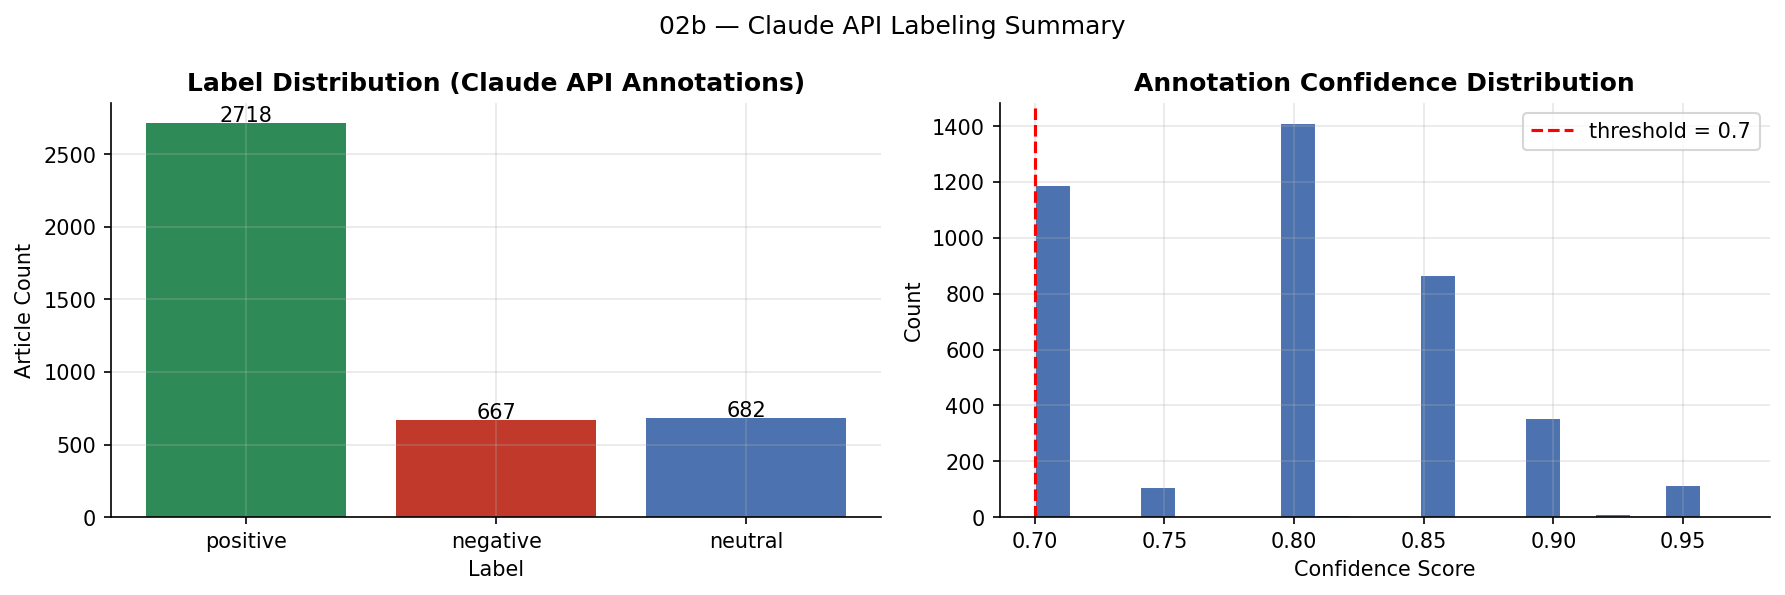

Saved figures/labeling_summary.png


In [21]:
# ── figure: labeling summary ──────────────────────────────────────────────────
label_counts = df_filtered["label"].value_counts().reindex(
    ["positive", "negative", "neutral"]
)
colors = ["#2E8B57", "#C0392B", "#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: label distribution
axes[0].bar(label_counts.index, label_counts.values,
            color=colors, edgecolor="none")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Article Count")
axes[0].set_title("Label Distribution (Claude API Annotations)", fontweight="bold")
for i, (lbl, val) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, val + 10, str(val), ha="center", fontsize=10)

# Histogram: confidence scores
axes[1].hist(df_filtered["confidence"], bins=20,
             color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[1].axvline(CONFIDENCE_THRESHOLD, color="red",
                linestyle="--", linewidth=1.5,
                label=f"threshold = {CONFIDENCE_THRESHOLD}")
axes[1].set_xlabel("Confidence Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Annotation Confidence Distribution", fontweight="bold")
axes[1].legend()

plt.suptitle("02b — Claude API Labeling Summary", fontsize=12)
plt.tight_layout()
plt.savefig("figures/labeling_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/labeling_summary.png")

In [22]:
# ── labeling summary table ────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Stage": [
        "Articles sampled from news_clean_ai.parquet",
        "Labeled by Claude API",
        f"After confidence >= {CONFIDENCE_THRESHOLD} filter",
    ],
    "Count": [
        N_SAMPLE,
        len(df_raw),
        len(df_filtered),
    ]
})
summary["Retained %"] = (summary["Count"] / N_SAMPLE * 100).round(1)
summary.to_csv("outputs/labeling_summary.csv", index=False)
print(summary.to_string(index=False))
print("\nSaved outputs/labeling_summary.csv")

                                      Stage  Count  Retained %
Articles sampled from news_clean_ai.parquet   5000       100.0
                      Labeled by Claude API   5000       100.0
             After confidence >= 0.7 filter   4067        81.3

Saved outputs/labeling_summary.csv


In [23]:
# ── labeling summary table ────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Stage": [
        "Articles sampled from news_clean_ai.parquet",
        "Labeled by Claude API",
        f"After confidence >= {CONFIDENCE_THRESHOLD} filter",
    ],
    "Count": [
        N_SAMPLE,
        len(df_raw),
        len(df_filtered),
    ]
})
summary["Retained %"] = (summary["Count"] / N_SAMPLE * 100).round(1)
summary.to_csv("outputs/labeling_summary.csv", index=False)
print(summary.to_string(index=False))
print("\nSaved outputs/labeling_summary.csv")

                                      Stage  Count  Retained %
Articles sampled from news_clean_ai.parquet   5000       100.0
                      Labeled by Claude API   5000       100.0
             After confidence >= 0.7 filter   4067        81.3

Saved outputs/labeling_summary.csv
